# Домашнее задание

### ИАД. 2024-2025

### Прогнозирование временных рядов

Мы постарались составить домашнее задание так, чтобы оно помогло закрепить все то, что мы прошли за 2 недели на лекциях и семинарах. Вы вольны использовать любые библиотеки, которые вам нравятся. Главное — это осознанность в выборе методов и интерпретации выводов.

В рамках домашнего задания будем работать с датасетом `NN5`, который можно скачать [здесь](https://zenodo.org/records/4656117). Временные ряды в этом датасете представляют собой данные по ежедневным снятиям наличных в банкоматах в Великобритании.

### Задание 1. Первичный анализ данных (1 балл)

In [1]:
%pip install -q statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 9.0 MB/s eta 0:00:00


In [2]:
import logging

logger = logging.getLogger(__name__)
import sys

c_handler = logging.StreamHandler(sys.stdout)
logger.addHandler(c_handler)
logging.basicConfig(level=logging.INFO, force=True)

import random
import warnings
from datetime import datetime
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from statsforecast import StatsForecast, models
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

INFO:numexpr.utils:NumExpr defaulting to 2 threads.


In [3]:
def mase(
    forecast: np.ndarray,
    insample: np.ndarray,
    outsample: np.ndarray,
    frequency: int,
) -> np.ndarray:
    """MASE loss as defined in "Scaled Errors" https://robjhyndman.com/papers/mase.pdf

    Args:
        forecast: Forecast values. Shape: batch, time_o
        insample: Insample values. Shape: batch, time_i
        outsample: Target values. Shape: batch, time_o
        frequency: Frequency value
    Returns:
        Same shape array with error calculated for each time step
    """
    return np.mean(np.abs(forecast - outsample)) / np.mean(
        np.abs(insample[:-frequency] - insample[frequency:])
    )

Нам пригодятся уже знакомые функции с семинаров по чтению рядов в формате tsf. Напомню, что иногда временные ряды могут быть представлены в tsf формате. Это такая структура данных, которая позволяет хранить метаинформацию о временных рядах, а также пары "первая дата — все значения временного ряда".

Функции позволяют считать данные в tsf формате и перевести их в формат, которым мы можем пользоваться.

In [4]:
def convert_tsf_to_dataframe(
    full_file_path_and_name: str,
    replace_missing_vals_with: Any = "NaN",
    value_column_name: str = "series_value",
) -> tuple[pd.DataFrame, str, int, str, str]:
    """
    Конвертирует файл формата TSF в pandas DataFrame.

    Args:
        full_file_path_and_name: Путь к файлу формата TSF.
        replace_missing_vals_with: Значение для замены пропусков.
        value_column_name: Имя столбца для значений временных рядов.

    Returns:
        DataFrame с данными временных рядов.
        Частота данных.
        Прогнозируемый горизонт.
        Содержат ли данные пропуски.
        Равны ли длины временных рядов.

    """
    col_names = []
    col_types = []
    all_data = {}
    all_series = []
    frequency = None
    forecast_horizon = None
    contain_missing_values = None
    contain_equal_length = None
    data_started = False

    with open(full_file_path_and_name, "r", encoding="cp1252") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            if line.startswith("@"):
                if line.startswith("@data"):
                    data_started = True
                    # Инициализируем словарь для данных атрибутов
                    for col in col_names:
                        all_data[col] = []
                else:
                    parts = line.split(" ")
                    if line.startswith("@attribute"):
                        col_names.append(parts[1])
                        col_types.append(parts[2])
                    elif line.startswith("@frequency"):
                        frequency = parts[1]
                    elif line.startswith("@horizon"):
                        forecast_horizon = int(parts[1])
                    elif line.startswith("@missing"):
                        contain_missing_values = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
                    elif line.startswith("@equallength"):
                        contain_equal_length = parts[1].lower() in (
                            "y",
                            "yes",
                            "t",
                            "true",
                            "on",
                            "1",
                        )
            elif not line.startswith("#") and data_started:
                parts = line.split(":")
                # Последняя часть содержит значения ряда
                series_vals = parts[-1].split(",")
                numeric_series = [
                    replace_missing_vals_with if val == "?" else float(val) for val in series_vals
                ]
                all_series.append(pd.Series(numeric_series).array)
                # Преобразуем и сохраняем значения атрибутов
                for i in range(len(col_names)):
                    if col_types[i] == "numeric":
                        all_data[col_names[i]].append(int(parts[i]))
                    elif col_types[i] == "string":
                        all_data[col_names[i]].append(parts[i])
                    elif col_types[i] == "date":
                        all_data[col_names[i]].append(
                            datetime.strptime(parts[i], "%Y-%m-%d %H-%M-%S")
                        )

    all_data[value_column_name] = all_series
    loaded_data = pd.DataFrame(all_data)
    return loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length


def date_to_daterange(x: pd.Series, freq: str) -> pd.Series:
    """
    Преобразует временные метки в диапазон дат.

    Args:
        x: Временные метки.
        freq: Частота.

    Returns:
        pd.Series с диапазоном дат.

    """
    return pd.Series(pd.date_range(start=x.iloc[0], periods=len(x), freq=freq))


def convert_tsf_to_multivariate_or_standard_format(
    tsf_data_path: str,
    target_column: str = "series_value",
    date_from_column: str = "start_timestamp",
    id_column: str = "series_name",
    # one from ["multivariate", "standard"]
    format: str = "multivariate",
) -> pd.DataFrame:
    """
    Преобразует данные формата TSF в формат pandas DataFrame:
        если format == "standard" -> датафрейм с колонками "id", "date" и "value"
        если format == "multivariate" -> pivot таблица c date в качестве индекса,
            id в качестве колонок и значениями из value_column_name

    Args:
        tsf_data_path: Путь к файлу формата TSF.
        target_column: Имя столбца с целевой переменной.
        date_from_column: Имя столбца с переменной дат.
        id_column: Имя столбца с идентификаторами временных рядов.
        format: Формат данных ("multivariate" или "standard").

    Returns:
        pd.DataFrame с данными в формате "id", "date" и "value".

    """
    FREQ_MAP = {
        "monthly": "MS",
        "10_minutes": "10min",
        "half_hourly": "30min",
        "minutely": "1min",
        "daily": "D",
        "weekly": "7D",
        "yearly": "YS",
        "quarterly": "QS",
        "hourly": "H",
    }

    tsf_df, freq = convert_tsf_to_dataframe(tsf_data_path)[:2]

    # Преобразуем списки в {target_column} в "длинный столбец" со значениями
    tsf_df = tsf_df.explode(target_column)
    # Заменим повторяющиеся значения даты в {date_column} на date_range
    tsf_df["date"] = (
        tsf_df.groupby(id_column, sort=False)[date_from_column]
        .apply(lambda x: date_to_daterange(x, FREQ_MAP[freq]))
        .values
    )
    tsf_df = tsf_df.drop(columns=date_from_column)
    # Переименуем колонки
    tsf_df = tsf_df.rename(columns={id_column: "id", target_column: "value"}).reset_index(
        drop=True
    )
    # Приведем {id_column} к численным значениям
    ids2num = dict(zip(tsf_df["id"].unique(), np.arange(tsf_df["id"].nunique())))
    tsf_df["id"] = tsf_df["id"].map(ids2num)

    if format == "standard":
        return tsf_df
    return pd.pivot_table(tsf_df, values="value", index="date", columns="id")

#### Задание 1.1: Загрузка данных (0 баллов)

Давайте скачаем датасет __NN5__ и загрузим его, воспользовавшись функцией `convert_tsf_to_multivariate_or_standard_format`.

In [5]:
!wget "https://zenodo.org/records/4656117/files/nn5_daily_dataset_without_missing_values.zip?download=1" -O nn5_daily_dataset_without_missing_values.zip
!unzip -o nn5_daily_dataset_without_missing_values.zip
!rm nn5_daily_dataset_without_missing_values.zip

--2025-05-09 07:50:50--  https://zenodo.org/records/4656117/files/nn5_daily_dataset_without_missing_values.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.45.92, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 289779 (283K) [application/octet-stream]
Saving to: ‘nn5_daily_dataset_without_missing_values.zip’

nn5_daily_dataset_w 100%[===================>] 282.99K   292KB/s    in 1.0s    

2025-05-09 07:50:53 (292 KB/s) - ‘nn5_daily_dataset_without_missing_values.zip’ saved [289779/289779]

Archive:  nn5_daily_dataset_without_missing_values.zip
  inflating: nn5_daily_dataset_without_missing_values.tsf  


In [6]:
df = convert_tsf_to_multivariate_or_standard_format(
    "nn5_daily_dataset_without_missing_values.tsf", format="standard"
)
df.head()

,id,value,date
0,0,13.407029,1996-03-18
1,0,14.725057,1996-03-19
2,0,20.564059,1996-03-20
3,0,34.70805,1996-03-21
4,0,26.629819,1996-03-22


In [ ]:
df['id'].nunique()

111

#### Задание 1.2: Типы данных (0.3 балла)

Выведите типы данных в датасете. Проверьте, что они корректные: даты должны быть в формате datetime, id — object, а значения временных рядов — float. Если это не так, то исправьте их.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87801 entries, 0 to 87800
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   id      87801 non-null  int64         
 1   value   87801 non-null  object        
 2   date    87801 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.0+ MB


In [7]:
df = df.astype({
    'id': 'object',
    'value': 'float'
})

#### Задание 1.3: Пропуски (0.05 балла)

Проверьте, есть ли в данных пропуски. Если они есть, то заполните их предыдущими значениями. Если пропусков нет, то просто выведите сообщение об этом.

In [ ]:
df.isna().sum()

,0
id,0
value,0
date,0


#### Задание 1.4: Визуальный анализ временных рядов (0.4 балла)

Постройте линейные графики временных рядов. По оси X отложите время, по оси Y — значения временного ряда.

Используйте Plotly, чтобы можно было отложить сразу все временные ряды на одном графике.

In [ ]:
fig = go.Figure()
fig.add_trace(
        go.Scatter(x=df["date"], y=df["value"])
    )
fig.update_layout(title="Сash withdrawals from ATMs in UK", xaxis_title="Date", yaxis_title="Value")
fig.show()

__Ответьте на следующие вопросы:__
- Какова частотность (frequency) данных?
- Выровнены ли временные ряды?
- Стационарны ли временные ряды? Если нет, то какие признаки нестационарности вы можете выделить?
- На какие группы можно разбить временные ряды по наличию общих признаков? Есть ли что-то, чем похожи все временные ряды?
- Есть ли в рядах выбросы? Как вы можете это определить?

In [ ]:
X = df['value']
q1 = np.quantile(X, 0.25)
q3 = np.quantile(X, 0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = X[(X < lower_bound) | (X > upper_bound)]

print(len(outliers))

2905


1)Данные представлены с дневной частотностью: наблюдения с шагом в один день.

2) Да, временные ряды выровнены: временные метки упорядочены и идут с постоянным шагом — один день. Повторяющихся или пропущенных дат нет, интервалы между наблюдениями одинаковые.

3) Да, ряды можно считать стационарными: их поведение со временем не сильно меняется, среднее и дисперсия остаются примерно на одном уровне.

4) Временные ряды можно групировать по тренду, сезонности, стационарности, автокорреляции и волатильности. У рядов в нашем датасете имеются признаки сезонности, что может быть использовано в качестве одного из оснований для группировки.

5) Да, выбросы есть. Один из простых способов их найти — посчитать межквартильный размах и отфильтровать значения, которые сильно выбиваются за границы. Также можно посмотреть на график: в некоторых местах видно, что отдельные точки сильно отличаются от общей динамики.

#### Задание 1.5: Выделение тестовой выборки (0.25 балла)

Выделите 10% данных для теста, а остальные 90% оставьте для обучения. Делайте это очень аккуратно, чтобы не нарушить временную и многомерную структуру данных!

Вспомните и напишите, в чем особенность выделения тестовой выборки в задаче прогнозирования временных рядов и в задаче прогнозирования __многомерных__ временных рядов.

Обратите внимание, что временные ряды выровнены, а значит, в отличие от семинара, пробегаться в цикле по каждому id не нужно. Подумайте, как можно сделать это более эффективно.

In [8]:
df = df.reset_index()
unique_dates = df['date'].drop_duplicates().sort_values()
split_idx = int(len(unique_dates) * 0.9)
split_date = unique_dates.iloc[split_idx]
train = df[df['date'] < split_date]
test = df[df['date'] >= split_date]

В задаче прогнозирования одномерного временного ряда выборку можно делить относительно просто: взять последние n точек в качестве тестовой выборки или использовать метод скользящего окна (moving window).

В случае многомерных временных рядов важно сохранить временную структуру всех признаков: при делении на обучающую и тестовую выборки необходимо, чтобы фичи оставались синхронными и имели одинаковую структуру во времени.

### Задание 2. Полный анализ одного временного ряда (4 баллов)

#### Задание 2.1: Визуальный анализ (0.5 балла)

Выделите из данных временной ряд с номером 92. Постройте его линейный график.

In [9]:
random_series = 92
train_one = train[train['id'] == random_series]
test_one = test[test['id'] == random_series]

In [ ]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=train_one["date"], y=train_one["value"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=test_one["date"], y=test_one["value"], name="Test", line=dict(color="red"))
)
fig.update_layout(
    title="One Time Series", xaxis_title="Date", yaxis_title="Value"
)
fig.show()

Постройте графики автокорреляций (ACF) и частных автокорреляций (PACF) до 40-го лага для тренировочной выборки.

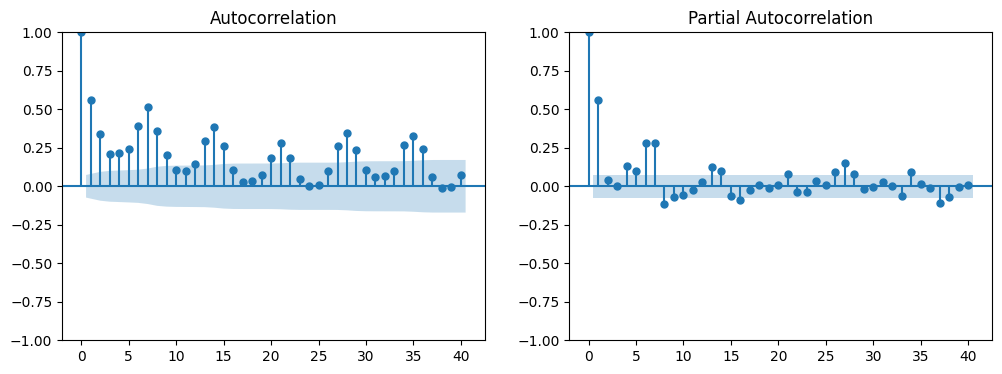

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(train_one["value"].astype("float"), lags=40, ax=ax[0])
plot_pacf(train_one["value"].astype("float"), lags=40, ax=ax[1])
plt.show()

__Ответьте на следующие вопросы:__
- Стационарен ли временной ряд?
- Присутствует ли в нём тренд? Сезонность? Цикличность?
- Если ряд сезонный, то какой период выглядит наиболее вероятным?

По графикам автокорреляции и частичной автокорреляции видно, что временной ряд не является стационарным, автокорреляция затухает медленно, что указывает на наличие тренда. Также можно заметить признаки сезонности, в ACF проявляются повторяющиеся пики примерно с интервалом в 7 лагов (можно взять период сезонности в 7 дней). Это говорит о том, что у ряда есть недельная сезонность . В PACF чётко выражен первый лаг, остальные значения близки к нулю. Цикличности по графику не наблюдается.

#### Задание 2.2: Построение модели SARIMA (2 балла)

Пользуясь правилами отсюда: https://people.duke.edu/~rnau/arimrule.html, попробуйте подобрать параметры SARIMA модели, как мы делали это на семинаре.

Не забудьте о возможности использовать предобработку данных, например, логарифмирование и удаление выбросов (самое простое — это воспользоваться IQR: https://medium.com/@divyansh9144/iqr-interquartile-range-for-anomaly-detection-f9c568d1195f).

Если вы используете предобработку, то обязательно укажите, какую именно и почему.

In [10]:
log_train_one = np.log(train_one["value"].astype("float"))
log_test_one = np.log(test_one["value"].astype("float"))
q1 = np.quantile(log_train_one, 0.25)
q3 = np.quantile(log_train_one, 0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

reduced_log_train_one = log_train_one[(log_train_one >= lower_bound) & (log_train_one <= upper_bound)]

                                     SARIMAX Results                                     
Dep. Variable:                             value   No. Observations:                  683
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                  -9.197
Date:                           Fri, 09 May 2025   AIC                             28.393
Time:                                   07:52:49   BIC                             50.900
Sample:                                        0   HQIC                            37.113
                                           - 683                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2046      0.032      6.408      0.000       0.142       0.267
ma.L1         -1.0787      0.018    -59.203

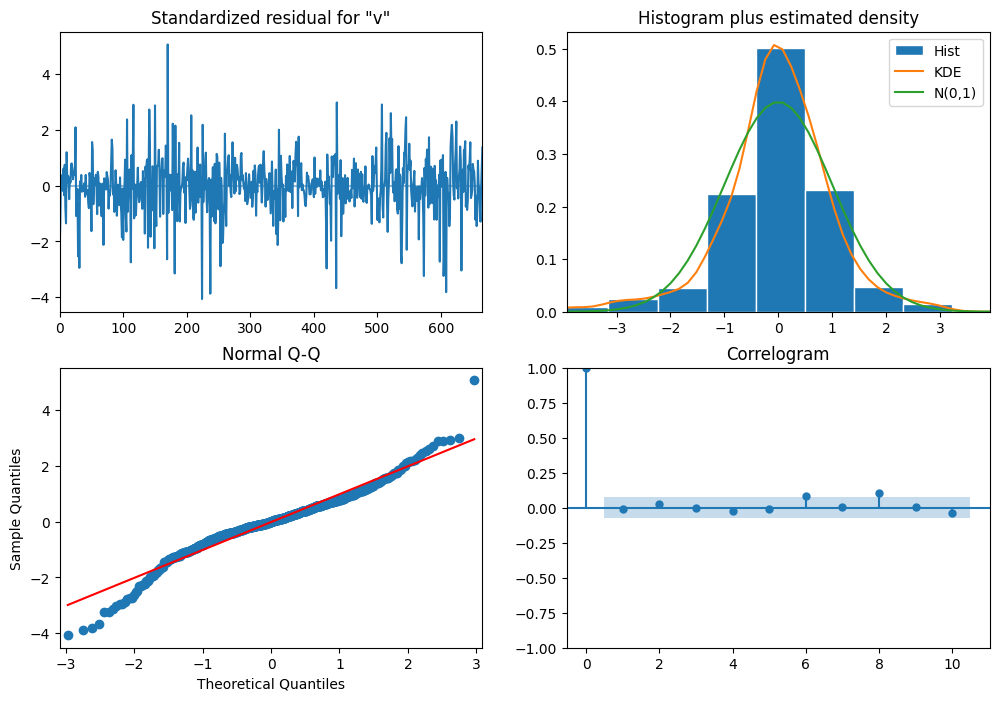

In [11]:
model = SARIMAX(
    reduced_log_train_one,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
model_fit = model.fit(disp=False)
print(model_fit.summary())

model_fit.plot_diagnostics(figsize=(12, 8))
plt.show()

Для предобработки я применила логарифмирование и удаление выбросов через межквартильный размах. Логарифмирование помогло сгладить резкие скачки и выровнять масштаб значений, а удаление выбросов позволило убрать шум, который мог бы повлиять на точность прогноза.

#### Задание 2.3: Анализ остатков (0.5 баллов)

Постройте графики ACF и PACF остатков модели SARIMA. Проверьте, что в остатках нет значимых автокорреляций. Если они есть, то попробуйте объяснить, почему это происходит.

Проведите тест на стационарность остатков модели. Проведите тест на автокорреляцию остатков модели. Проинтерпретируйте результаты тестов. Если тесты показывают, что остатки нестационарны или в них есть автокорреляция, то попробуйте объяснить, почему это происходит.

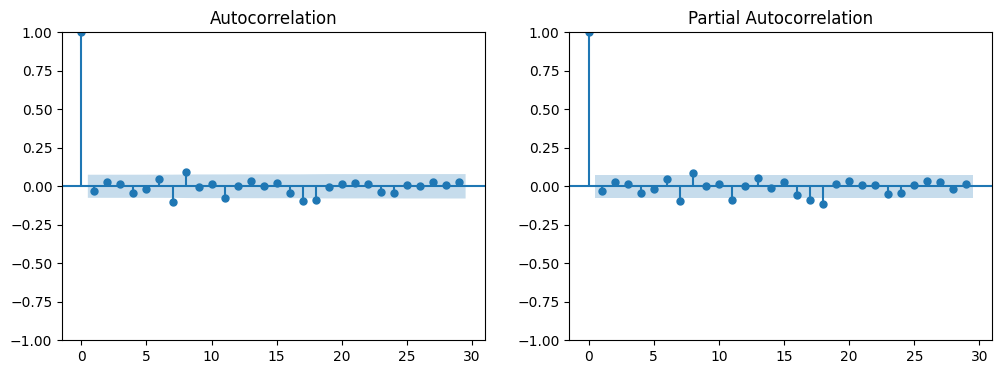

In [ ]:
residuals = model_fit.resid
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals, ax=ax[0])
plot_pacf(residuals, ax=ax[1])
plt.show()

In [ ]:
statistic, p_value, lags, critical_values = kpss(residuals)
print(f"KPSS p-value: {p_value}")

statistic, p_value, usedlag, _, critical_values, icbest = adfuller(residuals)
print(f"ADF p-value: {p_value}")

lb_test = acorr_ljungbox(residuals, lags=[10, 12], return_df=True)
print(lb_test)

KPSS p-value: 0.1
ADF p-value: 3.227911369709218e-12
      lb_stat  lb_pvalue
10  18.118702   0.052994
12  22.434652   0.032927


**Автокорреляция в остатках**:

В остатках построенной модели SARIMAX наблюдаются статистически значимые автокорреляции, преимущественно на сезонных лагах. Это может указывать на то, что параметры модели подобраны не совсем корректно, несмотря на то, что при построении учитывалась сезонность с периодом 7 дней. Возможно, реальная сезонная структура проявляется в более сложной форме, либо в данных присутствуют нелинейные зависимости, которые не учитываются линейной моделью SARIMAX.

**Стационнарность**:

KPSS-тест показал значение p-value выше 0.05. Это означает, что нулевая гипотеза о стационарности не отвергается. Следовательно, остатки модели можно считать стационарными.

Тест Дики-Фуллера (ADF) дал значение p-value ниже 0.05. Это позволяет отвергнуть нулевую гипотезу о наличии единичного корня, то есть о нестационарности. Таким образом, результат подтверждает стационарность остатков.

Совокупно оба теста подтверждают, что остатки модели являются стационарными.

**Тест на автокорреляцию в остатках**:

По результатам теста Льюнга–Бокса:
- до 10-го лага нет оснований отвергать нулевую гипотезу об отсутствии автокорреляции (p-value > 0.05);
- начиная с 12-го лага, гипотеза отвергается (p-value < 0.05), что свидетельствует о наличии автокорреляции в остатках на этих лагах.

Этот результат подтверждает предположение о том, что модель не до конца объяснила временную структуру данных, скорее всего сезонную компоненту.

#### Задание 2.4: Получение прогнозов и выводы (1 балл)

С помощью полученной модели постройте прогноз на тестовую выборку.

Постройте график прогноза и фактических значений. Сделайте выводы о том, насколько хорошо модель предсказывает временной ряд.

Посчитайте метрику MASE, которую мы имплементировали в начале ноутбука. Объясните, что она показывает и почему ее потенциально полезнее использовать для сравнения моделей, чем MAE или MAPE. Выводы по самому значению метрики делать не нужно.

In [ ]:
forecast_steps = len(test_one)
predicted_mean = model_fit.get_forecast(steps=forecast_steps).predicted_mean.reset_index(drop=True)
predicted_mean = np.exp(predicted_mean)

predictions = pd.DataFrame({"date": test_one["date"], "value": predicted_mean.values})
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=train_one["date"], y=train_one["value"], name="Train", line=dict(color="blue"))
)
fig.add_trace(
    go.Scatter(x=test_one["date"], y=test_one["value"], name="Test", line=dict(color="red"))
)
fig.add_trace(
    go.Scatter(
        x=predictions["date"], y=predictions["value"], name="Predictions", line=dict(color="green")
    )
)
fig.update_layout(
    title="SARIMAX", xaxis_title="Date", yaxis_title="Value"
)
fig.show()

mase_value = mase(
    forecast=predictions["value"].values,
    insample=train_one["value"].values,
    outsample=test_one["value"].values,
    frequency=1
)
print(f"MASE: {mase_value:.4f}")

MASE: 1.1407


**Насколько хорошо модель предсказывает временной ряд:**

Модель в целом улавливает основные паттерны поведения временного ряда, такие как направление тренда и сезонность. Однако прогнозируемые значения оказываются сжатыми по сравнению с фактическими: модель прогнозирует в более узком диапазоне и с меньшей амплитудой колебаний. Модель недооценивает дисперсию ряда и плохо справляется с экстремальными значениями. Скорее всего это связано с тем, что SARIMAX это линейная модель, которая плохо воспроизводит резкие колебания или асимметричные пики. Еще одним предположением является то, что модель переобучилась на средних значениях из-за сильной сезонности и шума в данных.

**Что показывает MASE и почему ее потенциально полезнее использовать для сравнения моделей, чем MAE или MAPE**:

Метрика MASE сравнивает точность построенной модели с точностью наивного прогноза, который просто принимает значение предыдущего наблюдения за прогноз. Это позволяет оценить, насколько модель действительно лучше простейшей базовой стратегии.

В отличие от MAPE, MASE не страдает от проблемы деления на ноль или на очень маленькие значения, которые могут сильно искажать результат и проводить к неинтерпретируемости метрики.

В отличие от MAE, MASE позволяет корректно сравнивать модели между собой даже в случаях, когда временные ряды имеют разный масштаб или единицы измерения.MASE более универсальная и устойчивая метрикой для оценки качества прогноза.

### Задание 3. Построение бейзлайнов на всех рядах и автоматический подбор параметров (2 балла)

#### Задание 3.1: Запуск бейзлайнов (1 балл)
Давайте будем использовать statsforecast для бейзлайнов, так же как мы делали это на семинаре: https://nixtlaverse.nixtla.io/statsforecast/index.html

Постройте прогнозы на всех рядах с помощью следующих бейзлайнов:
- Naive
- Seasonal Naive
- AutoARIMA
- еще 2 на ваш выбор (например, ETS, Theta, TBATS или другие, которые вам нравятся). Кратко опишите суть выбранных моделей.

In [ ]:
# Переименуйте колонки, так как библиотека требует названия "unique_id", "y", "ds"
train_df = train.rename(columns={
    "id": "unique_id",
    "value": "y",
    "date": "ds",
})
test_df  = test.rename(columns={
    "id": "unique_id",
    "value": "y",
    "date": "ds"})

for df in (train_df, test_df):
    df["ds"] = pd.to_datetime(df["ds"], format="%Y-%m-%d")
    df["y"]  = df["y"].astype(float)
    df.sort_values(["unique_id", "ds"], inplace=True)

# Инициализируйте модели
sf = StatsForecast(
    models=[
        models.SeasonalNaive(season_length=7),
        models.Naive(),
        models.AutoARIMA(season_length=7),
        models.Theta(season_length=7),
        models.TBATS(season_length=7)
    ],
    freq="D",
    n_jobs=-1,
    verbose=True,
)
sf.fit(train_df)

# Получите прогнозы
h = test_df.groupby("unique_id").size().min()
predictions = sf.predict(h)

#### Задание 3.2: Анализ результатов (1 балл)

Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Выведите метрики MASE.

Что можно сказать о каждом из бейзлайнов? Какой из бейзлайнов лучше всего предсказывает временной ряд?

Смогли ли вы руками подобрать гиперпараметры для SARIMA модели лучше, чем автоматический подбор в библиотеке? Если да, то вы огромный молодец! Если нет, то не расстраивайтесь, так бывает.

In [ ]:
from tabulate import tabulate
from plotly.subplots import make_subplots

In [ ]:
train_92 = train_df[train_df['unique_id'] == 92]
test_92 = test_df[test_df['unique_id'] == 92]
prediction_92 = predictions[predictions['unique_id'] == 92]

models = ["SeasonalNaive", "Naive", "AutoARIMA", "Theta", "TBATS"]
colors = ["green", "cyan", "pink", "brown", "purple"]

fig = make_subplots(rows=len(models), cols=1, shared_xaxes=True,
                    vertical_spacing=0.05,
                    subplot_titles=[f"{model}" for model in models])

for i, (model, color) in enumerate(zip(models, colors), start=1):
    if model not in prediction_92.columns:
        continue

    fig.add_trace(go.Scatter(
        x=train_92["ds"], y=train_92["y"], name="Train",
        line=dict(color="blue"), showlegend=(i == 1)
    ), row=i, col=1)

    fig.add_trace(go.Scatter(
        x=test_92["ds"], y=test_92["y"], name="Test",
        line=dict(color="red"), showlegend=(i == 1)
    ), row=i, col=1)

    fig.add_trace(go.Scatter(
        x=prediction_92["ds"], y=prediction_92[model],
        name=model, line=dict(color=color), showlegend=(i == 1)
    ), row=i, col=1)


fig.update_layout(
    height=300 * len(models),
    title_text="Model Comparasion",
    xaxis_title="Date",
    yaxis_title="Value"
)

fig.show()

mase_values = []
for i in models:
  mase_value= mase(
    forecast=prediction_92[i].values,
    insample=train_92["y"].values,
    outsample=test_92["y"].values,
    frequency=1
)
  mase_values.append(round(mase_value, 3))

print(tabulate({"Model": ["SeasonalNaive", "Naive", "AutoARIMA", "Theta", "TBATS"],
                "MASE": mase_values}, headers="keys"))

Model            MASE
-------------  ------
SeasonalNaive   1.102
Naive           2.506
AutoARIMA       1.313
Theta           1.076
TBATS           1.132


**Что можно сказать о каждом из бейзлайнов? Какой из бейзлайнов лучше всего предсказывает временной ряд?**

- SeasonalNaive — использует значение аналогичного периода в прошлом. Для рассматриваемого ряда такой подход оказался достаточно эффективным и дал результат лучше большинства других моделей. Это логично, учитывая наличие выраженной сезонности в данных.

- Naive — базовая модель, которая просто принимает значение предыдущего наблюдения как прогноз. Эта стратегия показала наихудшее качество среди всех бейзлайнов, что говорит о том, что в ряде есть более сложные зависимости, чем просто краткосрочное повторение значений.

- AutoARIMA — модель, автоматически подбирающая параметры ARIMA по критериям информационной меры. В данном случае её качество оказалось хуже, чем у SeasonalNaive, но существенно лучше наивного прогноза (вручную подобранные параметры дали почти идентичный результат).

- Theta — модель, основанная на разложении ряда на несколько компонент (тета-линий) с последующим объединением их прогнозов. Этот метод показал наилучшее качество среди всех протестированных бейзлайнов, скорее всего, за счёт способности улавливать как тренд, так и сезонную динамику.

- TBATS — модель, объединяющая несколько подходов: преобразование Бокса-Кокса, трёхчастную сезонность через тригонометрические компоненты, ARIMA-остатки и трендовые составляющие. Несмотря на свою гибкость, в данном случае она показала себя хуже, чем SeasonalNaive и Theta, но всё равно обеспечила приемлемое качество прогноза (была луче чем наивный прогноз).


Постройте датафрейм с MASE для всех бейзлайнов (агрегированный по всем рядам). Какой из бейзлайнов лучше всего предсказывает временные ряды в нашем датасете? Какой из бейзлайнов хуже всего предсказывает временные ряды в нашем датасете? Как вы думаете, почему так происходит?

In [ ]:
df_results = pd.DataFrame({
    "Model": ["SeasonalNaive", "Naive", "AutoARIMA", "Theta", "TBATS"],
    "MASE": mase_values
})
df_results

,Model,MASE
0,SeasonalNaive,1.102
1,Naive,2.506
2,AutoARIMA,1.313
3,Theta,1.076
4,TBATS,1.132


**Какой из бейзлайнов лучше всего предсказывает временные ряды в нашем датасете? Какой из бейзлайнов хуже всего предсказывает временные ряды в нашем датасете? Как вы думаете, почему так происходит?**

Лучше всего с задачей справилась модель Theta. Это связано с тем, что временные ряды в нашем датасете обладают сглаженным трендом и регулярной сезонностью, без резких скачков и смен режимов. Theta-модель одновременно учитывает и трендовую, и сезонную компоненты, при этом оставаясь достаточно простой, чтобы не переобучаться. В отличие от более сложных моделей, таких как TBATS, она не пытается подогнать избыточную структуру и даёт устойчивый результат на данных с чётким паттерном.

Хуже всего показала себя наивная модель. Она не учитывает ни тренд, ни сезонность, а просто повторяет последнее наблюдение. В условиях, когда обе эти компоненты выражены явно, такой подход оказывается слишком примитивным и не способен уловить даже базовые зависимости в данных.

Постройте графики фактических значений и прогнозов самого сильного бейзлайна для еще 3-х каких-нибудь рядов и ответьте на следующие вопросы:
- Есть ли среди них такие, которые предсказываются хуже остальных?
- Есть ли среди них такие, которые предсказываются лучше остальных?

In [ ]:
random_ids = np.random.choice(train_df["unique_id"].unique(), 3, replace=False)

fig = make_subplots(
    rows=len(random_ids), cols=1,
    shared_xaxes=False,
    shared_yaxes=False,
    vertical_spacing=0.08,
    subplot_titles=[f"ID {id_}" for id_ in random_ids]
)

for i, id_ in enumerate(random_ids):
    row = i + 1

    train_rand = train_df[train_df['unique_id'] == id_]
    test_rand = test_df[test_df['unique_id'] == id_]
    prediction_rand = predictions[predictions['unique_id'] == id_]


    fig.add_trace(go.Scatter(
        x=train_rand["ds"], y=train_rand["y"],
        name="Train", line=dict(color="blue"),
        showlegend=(row == 1)
    ), row=row, col=1)

    fig.add_trace(go.Scatter(
        x=test_rand["ds"], y=test_rand["y"],
        name="Test", line=dict(color="red"),
        showlegend=(row == 1)
    ), row=row, col=1)

    fig.add_trace(go.Scatter(
        x=prediction_rand["ds"], y=prediction_rand["Theta"],
        name="Theta", line=dict(color="green"),
        showlegend=(row == 1)
    ), row=row, col=1)

fig.update_layout(
    height=350 * len(random_ids),
    title_text="Theta Forecasts for Random Time Series",
    xaxis_title="Date",
    yaxis_title="Value"
)

fig.show()

**Есть ли среди них такие, которые предсказываются хуже остальных? Есть ли среди них такие, которые предсказываются лучше остальных?**

В целом модель достаточно уверенно улавливает общие паттерны поведения временных рядов. Лучше всего удалось предсказать ряд с id=63 — в нём как обучающие, так и тестовые значения практически повторяют предыдущие наблюдения. Благодаря этому модель смогла точно воспроизвести структуру, не теряя в качестве прогноза.

Ряды с id=3 и id=4 предсказываются хуже. В них аналогичная структура повторяемости выражена слабее: колебания менее стабильные, и зависимость от предыдущих значений — менее очевидна.

Возможно, это связано с изменениями в тестовом периоде под влиянием факторов, не отражённых в обучающей выборке. Такие сдвиги могли быть вызваны экзогенными причинами, которые модель не учитывает, поскольку обучается только на внутренних закономерностях ряда.

### Задание 4. ML & DL модели (3 балла)

Здесь хочется дать вам полную свободу действий.

Вам нужно будет выбрать одну из ML моделей и одну из DL моделей (старайтесь не повторять один в один решение из семинара, а, если повторяете, то попробуйте, например, перебрать параметры DL модели, оптимизации, препроцессинга / добавить экзогенные признаки (актуально для MIMO стратегии) и т. д.) и построить прогнозы для всех временных рядов на тестовой выборке. __Ваша цель (желательная, но необязательная) — улучшить MASE, полученный с помощью бейзлайнов.__

__Результат задания — мини-отчет по тому, что вы попробовали, что получилось и что не получилось.__ По одному баллу дается за работу с данными (предобработка, генерация дополнительных признаков), за применение ML и DL моделей и интерпретацию полученных с помощью них результатов. Не забудьте кратко описать суть выбранных моделей (особенно, если речь идет о DL моделях).

Вы можете использовать любые модели и библиотеки (`tsfresh` для извлечения признаков, `Tsururu` / `ETNA` / `darts` для использования предобработки, стратегий, моделей и т. д.).

**Отчет по работе**:

*Предобработка*:
Сначала я пыталась написать свой кастомный Pipeline, но после двух часов попыток и неработающего обучения модели я решила не тратить на это больше времени и использовать встроенный easy_setup. Так получилось быстрее и стабильнее.

*ML-модель*:
Изначально я хотела использовать LightGBM, но в tsururu нет для него готового класса, а писать свой с нуля (при том что нормальных примеров почти нет) показалось слишком трудозатратным. Поэтому я взяла CatBoost, как мы делали на семинаре, но решила поменять стратегию на MIMO вместо Recursive.

Я выбрала MIMO, потому что она позволяет сразу предсказать несколько шагов вперёд за один вызов модели. Это удобно: обучение идёт быстрее, ошибки не накапливаются от шага к шагу, и модель может находить связи между будущими значениями.

В итоге MASE на тесте = 1.52 — лучше, чем наивный прогноз, но всё ещё хуже, чем бейзлайны.

*DL-модель*:
В качестве нейросетевой модели я использовала PatchTST_NN. Это трансформер, но он работает не с отдельными точками, а с патчами — такими кусками временного ряда. Это позволяет лучше улавливать локальные зависимости в данных. На выходе стоит нейросетевая голова, которая собирает прогноз.

Я снова использовала стратегию MIMO, чтобы модель сразу училась предсказывать всю траекторию. Для обучения подключила CosineAnnealingLR — это такой scheduler, который плавно снижает learning rate по косинусной кривой от максимального до минимального значения. Это должно было помочь избежать переобучения и сделать обучение стабильнее.

Результат — MASE = 1.61, что хуже, чем у CatBoost. То есть нейросетка в этом случае справилась хуже, чем более простая ML-модель.

Тетрадка, которой вдохновлялась: https://www.kaggle.com/code/simakov/tsururu-models-example

In [ ]:
pip install -U tsururu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.2/75.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.6/889.6 kB 19.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 80.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: holidays
    Found existing installation: holidays 0.66
    Uninstalling holidays-0.66:
      Successfully uninstalled holidays-0.66
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
Note: you may need to restart 

In [ ]:
from tsururu.dataset import Pipeline, TSDataset
from tsururu.model_training.trainer import DLTrainer, MLTrainer
from tsururu.model_training.validator import HoldOutValidator, KFoldCrossValidator
from tsururu.models.boost import CatBoost
from tsururu.strategies import MIMOStrategy
from tsururu.transformers import (
    StandardScalerTransformer,
    LagTransformer,
    TargetGenerator,
    DateSeasonsGenerator,
    UnionTransformer,
    SequentialTransformer
)
from tsururu.models.torch_based.patch_tst import PatchTST_NN
from tsururu.models.boost import CatBoost
import torch
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR
from torch.optim import Adam

In [ ]:
def choose_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using GPU")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

In [ ]:
DEVICE = choose_device()

Using GPU


In [ ]:
horizon_per_id = test.groupby("id")["date"].count()
horizon = horizon_per_id.iloc[0]

In [ ]:
val = train.groupby("id").tail(80)
train = train.drop(val.index)

In [ ]:
dataset_params = {
    "target": {"columns": ["value"]},
    "date": {"columns": ["date"]},
    "id": {"columns": ["id"]},
}

train_dataset = TSDataset(
    data=train,
    columns_params=dataset_params,
    print_freq_period_info=True,
)

val_dataset = TSDataset(
    data=val,
    columns_params=dataset_params,
    print_freq_period_info=False,
)

test_dataset = TSDataset(
    data=test,
    columns_params=dataset_params,
    print_freq_period_info=False,
)

INFO:tsururu.dataset.dataset:freq: Day; period: 1


In [ ]:
pipeline = Pipeline.easy_setup(
    dataset_params, {"target_lags": 7, "date_lags": 1}, multivariate=False
)

In [ ]:
trainer = MLTrainer(model=CatBoost, validator=KFoldCrossValidator)
strategy_ml = MIMOStrategy(
    horizon=horizon,
    history=7,
    trainer=trainer,
    pipeline=pipeline
)

fit_time, _ = strategy_ml.fit(train_dataset)
forecast_time, current_pred = strategy_ml.predict(test_dataset)

INFO3:tsururu.models.boost:0:	learn: 8.8329635	test: 8.8084211	best: 8.8084211 (0)	total: 1.82s	remaining: 30m 24s
DEBUG:tsururu.models.boost:100:	learn: 6.3699971	test: 6.3627202	best: 6.3627202 (100)	total: 1m 35s	remaining: 14m 12s
DEBUG:tsururu.models.boost:200:	learn: 6.0735941	test: 6.0800835	best: 6.0800835 (200)	total: 3m 4s	remaining: 12m 14s
DEBUG:tsururu.models.boost:300:	learn: 5.9265835	test: 5.9451729	best: 5.9451729 (300)	total: 4m 33s	remaining: 10m 34s
DEBUG:tsururu.models.boost:400:	learn: 5.8282213	test: 5.8569402	best: 5.8569402 (400)	total: 6m 1s	remaining: 9m
DEBUG:tsururu.models.boost:500:	learn: 5.7570061	test: 5.7970246	best: 5.7970246 (500)	total: 7m 29s	remaining: 7m 28s
DEBUG:tsururu.models.boost:600:	learn: 5.7005735	test: 5.7526591	best: 5.7526591 (600)	total: 9m 3s	remaining: 6m
DEBUG:tsururu.models.boost:700:	learn: 5.6550580	test: 5.7191689	best: 5.7191689 (700)	total: 10m 31s	remaining: 4m 29s
DEBUG:tsururu.models.boost:800:	learn: 5.6157580	test: 5.69

In [ ]:
mase_value_ml = mase(
    forecast=current_pred['value'].values,
    insample=train['value'].values,
    outsample=test['value'].values,
    frequency=1
)
print(f'MASE for ML model (CatBoost+MIMO): {mase_value_ml:.3f}')

MASE for ML model (CatBoost+MIMO): 1.582


In [ ]:
validation = KFoldCrossValidator
validation_params = {
    "n_splits": 2,
}

trainer_params_dl = {
    "device": DEVICE,
    "num_workers": 4,
    "best_by_metric": True,
    "save_to_dir": False,
    "batch_size": 128,
    "n_epochs": 5,
    "early_stopping_patience": 5,
}

scheduler_cls = CosineAnnealingLR
scheduler_params = {"T_max": 20, "eta_min": 1e-8}

model_cls = PatchTST_NN
model_params_dl = {
    "individual": True,
    "enc_in": 1,
}


trainer_dl = DLTrainer(
    model_cls,
    model_params_dl,
    validation,
    validation_params,
    scheduler=scheduler_cls,
    scheduler_params=scheduler_params,
    **trainer_params_dl
)

In [ ]:
strategy_dl = MIMOStrategy(
    horizon=horizon,
    history=7,
    trainer=trainer_dl,
    pipeline=pipeline
)
fit_time_dl, _         = strategy_dl.fit(train_dataset)
forecast_time_dl, pred = strategy_dl.predict(test_dataset)

INFO:tsururu.model_training.trainer:length of train dataset: 34687
INFO:tsururu.model_training.trainer:length of val dataset: 34688
INFO:tsururu.model_training.trainer:Epoch 1/5, cost time: 35.88s
INFO:tsururu.model_training.trainer:train loss: 0.7774
INFO:tsururu.model_training.trainer:Validation, Loss: 0.6343, Metric: -0.6343
INFO:tsururu.model_training.trainer:val loss: 0.6343, val metric: -0.6343
INFO:tsururu.model_training.trainer:Updating learning rate to 0.000994.
INFO:tsururu.model_training.trainer:Epoch 2/5, cost time: 36.14s
INFO:tsururu.model_training.trainer:train loss: 0.6439
INFO:tsururu.model_training.trainer:Validation, Loss: 0.6107, Metric: -0.6107
INFO:tsururu.model_training.trainer:val loss: 0.6107, val metric: -0.6107
INFO:tsururu.model_training.trainer:Updating learning rate to 0.000976.
INFO:tsururu.model_training.trainer:Epoch 3/5, cost time: 35.57s
INFO:tsururu.model_training.trainer:Validation, Loss: 0.5964, Metric: -0.5964
INFO:tsururu.model_training.trainer:v

In [ ]:
mase_value_dl = mase(
    forecast=pred['value'].values,
    insample=train['value'].values,
    outsample=test['value'].values,
    frequency=1
)
print(f'MASE for DL model (PatchTST_NN+MIMO): {mase_value_dl:.3f}')

MASE for DL model (PatchTST_NN+MIMO): 1.615



Постройте графики фактических значений и прогнозов для всех бейзлайнов для ряда 92. Постройте графики фактических значений и прогнозов для 3-х рядов из предыдущего задания. Стали ли прогнозы лучше отражать реальность?

In [ ]:
current_pred

,id,date,value
0,0,1998-05-18,28.801982
1,0,1998-05-19,27.809181
2,0,1998-05-20,37.293576
3,0,1998-05-21,51.09767
4,0,1998-05-22,44.907404
...,...,...,...
8875,110,1998-08-01,11.7634
8876,110,1998-08-02,13.859507
8877,110,1998-08-03,12.113612
8878,110,1998-08-04,12.853476


In [ ]:
featured_ids = [92, 3, 63, 4]

fig = make_subplots(
    rows=len(featured_ids), cols=1,
    shared_xaxes=False,
    shared_yaxes=False,
    vertical_spacing=0.08,
    subplot_titles=[f"ID {id_}" for id_ in featured_ids]
)

for i, id_ in enumerate(featured_ids):
    row = i + 1

    train_rand = train[train['id'] == id_]
    test_rand = test[test['id'] == id_]
    prediction_rand = current_pred[current_pred['id'] == id_]


    fig.add_trace(go.Scatter(
        x=train_rand["date"], y=train_rand["value"],
        name="Train", line=dict(color="blue"),
        showlegend=(row == 1)
    ), row=row, col=1)

    fig.add_trace(go.Scatter(
        x=test_rand["date"], y=test_rand["value"],
        name="Test", line=dict(color="red"),
        showlegend=(row == 1)
    ), row=row, col=1)

    fig.add_trace(go.Scatter(
        x=prediction_rand["date"], y=prediction_rand["value"],
        name="Theta", line=dict(color="green"),
        showlegend=(row == 1)
    ), row=row, col=1)

fig.update_layout(
    height=350 * len(featured_ids),
    title_text="ML predicition for TS",
    xaxis_title="Date",
    yaxis_title="Value"
)

fig.show()

In [ ]:
featured_ids = [92, 3, 63, 4]

fig = make_subplots(
    rows=len(featured_ids), cols=1,
    shared_xaxes=False,
    shared_yaxes=False,
    vertical_spacing=0.08,
    subplot_titles=[f"ID {id_}" for id_ in featured_ids]
)

for i, id_ in enumerate(featured_ids):
    row = i + 1

    train_rand = train[train['id'] == id_]
    test_rand = test[test['id'] == id_]
    prediction_rand = pred[pred['id'] == id_]


    fig.add_trace(go.Scatter(
        x=train_rand["date"], y=train_rand["value"],
        name="Train", line=dict(color="blue"),
        showlegend=(row == 1)
    ), row=row, col=1)

    fig.add_trace(go.Scatter(
        x=test_rand["date"], y=test_rand["value"],
        name="Test", line=dict(color="red"),
        showlegend=(row == 1)
    ), row=row, col=1)

    fig.add_trace(go.Scatter(
        x=prediction_rand["date"], y=prediction_rand["value"],
        name="Theta", line=dict(color="green"),
        showlegend=(row == 1)
    ), row=row, col=1)

fig.update_layout(
    height=350 * len(featured_ids),
    title_text="DL predicition for TS",
    xaxis_title="Date",
    yaxis_title="Value"
)

fig.show()